# El Ecosistema Keras y APIs: Arquitectura de Software en Deep Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/06_ecosistema_keras_y_apis.ipynb)

## Objetivos


- Comprender la diferencia arquitectónica entre **TensorFlow** (motor de tensores) y **Keras** (API de alto nivel), y la revolución Multi-backend de Keras 3.0.
- Conocer el espectro de APIs de Keras: *Sequential*, *Functional* y *Subclassing*.
- **Dominar la API Funcional:** Construir grafos acíclicos dirigidos (DAGs) para modelos complejos con múltiples entradas y salidas.
- Aprender a inspeccionar la topología interna de un modelo y extraer características intermedias (*Feature Extraction*).



## Prerrequisitos


- Entendimiento de la topología básica de una red neuronal (Capas, Entradas, Salidas).
- Haber completado: [El Ciclo de Entrenamiento y Diagnóstico](05_ciclo_entrenamiento_y_diagnostico.ipynb).

---


## Configuración del Entorno


In [2]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

# CRITERIO DE INGENIERÍA: Keras 3.0 Multi-backend
# A partir de Keras 3, podemos elegir qué motor matemático usar por debajo.
# Cambiando esta variable a "torch" o "jax", el mismo código de Keras correrá en PyTorch o JAX.
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Reproducibilidad
keras.utils.set_random_seed(42)

print(f"Keras versión: {keras.__version__} | Backend: {keras.backend.backend()}")
print(f"TensorFlow versión: {tf.__version__}")

Keras versión: 3.13.2 | Backend: tensorflow
TensorFlow versión: 2.20.0


## 1. El Ecosistema: Separando el Motor del Volante



Es muy común que los principiantes confundan TensorFlow con Keras, usándolos como sinónimos. Como ingenieros, debemos entender la pila tecnológica (*Tech Stack*).

* **TensorFlow / PyTorch / JAX:** Son la infraestructura de bajo nivel. Se encargan de la manipulación de tensores, la diferenciación automática (cálculo de derivadas) y la distribución del cómputo en el hardware (CPU, GPU, TPU). Son el "motor" del auto.
* **Keras:** Es una API de alto nivel diseñada para la cognición humana. Se encarga de las capas, los modelos, los optimizadores y las métricas. Es el "volante y los pedales".


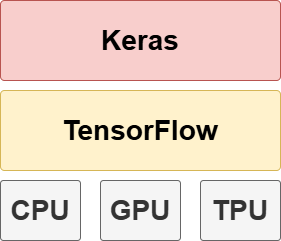

*(Figura: La separación de responsabilidades entre Keras, el motor de tensores y el hardware. Adaptado de Deep Learning with Python, F. Chollet).*

> **La Revolución de Keras 3.0:** Históricamente, Keras estaba atado exclusivamente a TensorFlow. Hoy, Keras es **Multi-backend**. Podemos escribir la arquitectura del modelo una sola vez en Keras, y decidir mediante una variable de entorno (`os.environ["KERAS_BACKEND"] = "torch"`) si queremos que se ejecute sobre TensorFlow, PyTorch o JAX. Esto es casi que un superpoder de ingeniería de software que evita el *vendor lock-in*.

## 2. El Espectro de APIs: De Principiante a Investigador


Keras ofrece tres formas distintas de construir modelos, dependiendo de los objetivos y del nivel de experiencia. No hay una "mejor" que otra; hay una herramienta adecuada para cada problema.

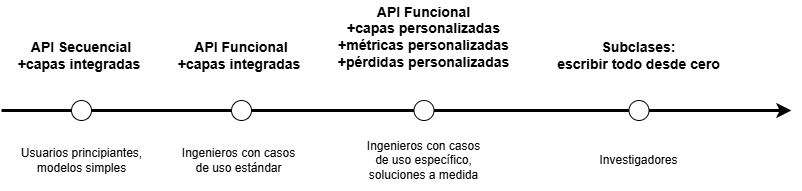

*(Figura: El espectro de APIs de Keras, desde la simplicidad hasta la flexibilidad absoluta. Adaptado de Deep Learning with Python, F. Chollet).*

### A. La API Secuencial (*Sequential API*): Formas de Construcción e Inspección


Es la que venimos usando hasta ahora, la que aparecía en los ejemplos de notebooks anteriores. Es literalmente una lista de Python donde apilamos capas una detrás de otra.
- **Ventaja:** Extremadamente fácil de leer y escribir.
- **Desventaja:** Solo permite topologías lineales (Entrada -> Capa 1 -> Capa 2 -> Salida).

#### **Método 1: Como una lista de Python (Ideal para modelos cortos)**

In [4]:
from keras import layers, Model

modelo_lista = keras.Sequential([
    keras.Input(shape=(784,), name="Capa_Entrada"),
    layers.Dense(128, activation="relu", name="Oculta_1"),
    layers.Dense(10, activation="softmax", name="Salida")
], name="Modelo_Lista")

Una vez construido, el primer paso es verificar que las dimensiones (`shapes`) coincidan con lo planeado.

La inspección de la arquitectura se realiza con `model.summary()`

In [5]:
modelo_lista.summary()

Model: "Modelo_Lista"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Oculta_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**¿Cómo leer el Summary?**  
1. **Output Shape:** Muestra `(None, 128)`. El `None` representa el tamaño del lote (*Batch Size*), indicando que el modelo acepta lotes de cualquier tamaño. El `128` son las neuronas de esa capa.
2. **Param #:** Es la cantidad de pesos y sesgos (*biases*). Para una capa densa, la fórmula es: `(Entradas * Neuronas) + Neuronas`. Ej: `(784 * 128) + 128 = 100.480`.
3. **Trainable params:** Los pesos que el optimizador actualizará. (En *Transfer Learning*, veremos cómo "congelar" capas, lo que moverá estos parámetros a *Non-trainable*).

#### **Método 2: Usando el método `.add()`**

Ideal para utilizar con bucles `for` y crear capas dinámicamente, también aparecía esta forma en varios de los ejemplos ya abordados.

In [10]:
modelo_add = keras.Sequential(name="Modelo_Add")
modelo_add.add(keras.Input(shape=(784,)))
for i in range(5):
    modelo_add.add(layers.Dense(128, activation="relu", name=f"Oculta_{i+1}"))
modelo_add.add(layers.Dense(10, activation="softmax", name="Salida"))

modelo_add.summary()

Model: "Modelo_Add"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Oculta_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_4 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_5 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

> **⚠️ TRAMPA DEL PRINCIPIANTE (La Capa `Input`):**   
> En Keras, podemos omitir la capa `keras.Input`. Si lo hacemos, el código no fallará inmediatamente, pero el modelo **no tendrá pesos ni forma** hasta que le pasemos datos por primera vez (llamando a `.fit()` o `.predict()`). Si intentamos hacer un `model.summary()` sin haber definido el `Input`, Keras lanzará un error.

**Criterio de Ingeniería:** Definir SIEMPRE explícitamentel el `keras.Input`. Sirve también para estar conscientes de lo que debe ENTRAR y SALIR del modelo, y validar dicha consistencia con el `shape` de los datos.


### B. La API Funcional (*Functional API*)


El estándar de la industria. Trata a las capas como funciones matemáticas que reciben tensores y devuelven tensores. Permite construir grafos complejos (múltiples entradas, múltiples salidas, conexiones residuales).
- **Ventaja:** Equilibrio perfecto entre flexibilidad y usabilidad. El modelo sigue siendo un grafo estático inspeccionable.



### C. Subclases de Modelos (*Model Subclassing*)


Programación orientada a objetos pura. Hereda de `keras.Model` y se escribe el *Forward Pass* desde cero en el método `call()`.
- **Ventaja:** Control absoluto. Podemos usar bucles `for`, condicionales `if` y lógica dinámica.
- **Desventaja:** Keras pierde la capacidad de inspeccionar el grafo estáticamente (no podemos usar `plot_model` fácilmente ni inferir formas automáticamente). Reservado para investigadores creando arquitecturas exóticas/nuevas.

## 3. Dominando la API Funcional (El Estándar de la Industria)


Para entender por qué la API Secuencial se queda corta, imaginemos un problema real de ingeniería.

**El Caso de Estudio:** Supongamos que estamos creando un sistema de IA para clasificar los tickets de atención al cliente de una empresa de software. Nuestro modelo debe recibir **tres entradas distintas**:
1. El título del ticket (Texto, codificado como una matriz de vocabulario de 10.000 palabras).
2. El cuerpo del ticket (Texto, codificado igual que el título).
3. Etiquetas agregadas por el usuario (Datos categóricos, ej. 100 etiquetas posibles codificadas en *One-Hot*).

Y debe generar **dos salidas simultáneas**:
1. Una puntuación de prioridad entre 0 y 1 (para saber si es urgente).
2. El departamento al que debe enviarse (Clasificación multiclase entre 4 departamentos).

**Es matemáticamente imposible construir esto con `keras.Sequential`.** Necesitamos la API Funcional.

### Construyendo el Grafo Paso a Paso



En la API Funcional, primero definimos los "cables" (Tensores de Entrada) y luego pasamos esos cables a través de las "cajas" (Capas).



In [11]:
# 1. Definimos las dimensiones de nuestros datos
vocab_size = 10000
num_tags = 100
num_departments = 4

# 2. Definimos las ENTRADAS (Los "cables" iniciales)
# name="" es crucial en modelos complejos para no perdernos
title_input = keras.Input(shape=(vocab_size,), name="title")
body_input = keras.Input(shape=(vocab_size,), name="body")
tags_input = keras.Input(shape=(num_tags,), name="tags")

# 3. Procesamiento independiente de cada entrada
# Observa la sintaxis: Capa(configuración)(tensor_de_entrada)
features_title = layers.Dense(64, activation="relu")(title_input)
features_body = layers.Dense(64, activation="relu")(body_input)
features_tags = layers.Dense(32, activation="relu")(tags_input)

# 4. Fusión de la información (El poder de los grafos)
# Concatenamos las características extraídas en un solo vector gigante
features = layers.Concatenate()([features_title, features_body, features_tags])

# Añadimos una capa densa intermedia para procesar la información combinada
features = layers.Dense(64, activation="relu")(features)

# 5. Definimos las SALIDAS
# Salida 1: Prioridad (Regresión logística -> Sigmoide)
priority_output = layers.Dense(1, activation="sigmoid", name="priority")(features)

# Salida 2: Departamento (Clasificación multiclase -> Softmax)
department_output = layers.Dense(num_departments, activation="softmax", name="department")(features)

# 6. Instanciamos el Modelo final
ticket_model = Model(
    inputs=[title_input, body_input, tags_input],
    outputs=[priority_output, department_output],
    name="Ticket_Routing_Model"
)

# Compilamos el modelo especificando una función de pérdida para CADA salida
ticket_model.compile(
    optimizer="adam",
    loss={
        "priority": "binary_crossentropy",
        "department": "categorical_crossentropy",
    },
    metrics={
        "priority": ["mae"],
        "department": ["accuracy"],
    }
)

### Visualizando la Arquitectura



Una de las mayores ventajas de la API Funcional es que Keras construye un grafo estático en memoria. Esto nos permite auditar visualmente la arquitectura usando `plot_model`.



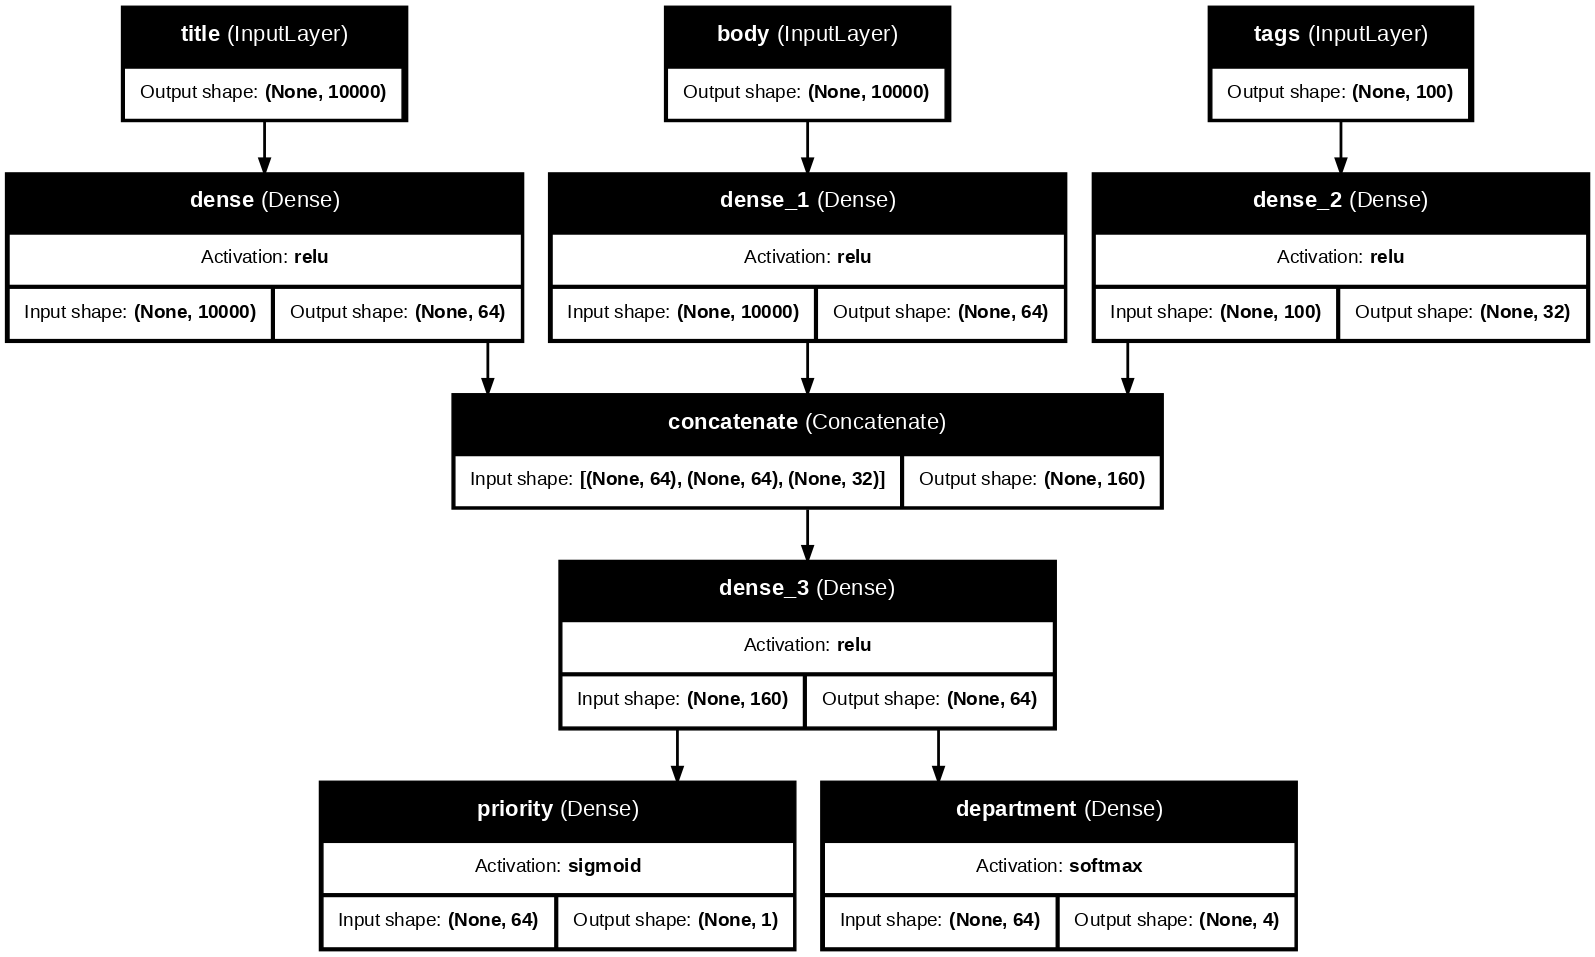

In [12]:
# Generamos un diagrama visual del modelo
keras.utils.plot_model(
    ticket_model,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    dpi=100
)


*(Notar que se renderiza un diagrama de flujo que muestra cómo los tres inputs se procesan, se concatenan y se dividen en dos outputs).*

Con el `model.summary()`, esto no es tan claro...

In [13]:
ticket_model.summary()

Model: "Ticket_Routing_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body (InputLayer)   │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    640,064 │ title[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │    640,064 │ body[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      3,232 │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority (Dense)    │ (None, 1)         │         65 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ department (Dense)  │ (None, 4)         │        260 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,293,989 (4.94 MB)

 Trainable params: 1,293,989 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

Tanto al observar el diagrama o el `summary()`, las "formas" de los tensores dicen `(None, 10000)` o `(None, 64)`. Ya lo mencionamos brevemente arriba, pero es mejor algo de redundancia...

¿Qué significa ese `None`? **Representa el tamaño del lote (*Batch Size*).**  
Al diseñar la arquitectura, no queremos atar el modelo a un tamaño de lote específico. El `None` le dice a Keras: *"Esta dimensión puede ser de cualquier tamaño"*. Así, el mismo modelo puede procesar un lote de 32 tickets durante el entrenamiento, y un lote de 1 solo ticket cuando esté desplegado en producción haciendo inferencia en tiempo real.

## 4. Inspección de Grafos y Extracción de Características



El acceso a la conectividad de las capas significa que podemos inspeccionar y reutilizar nodos individuales dentro del grafo. Esto es la base de técnicas avanzadas como el ***Transfer Learning*** (que veremos en profundidad más adelante).

La propiedad `model.layers` nos da una lista de todas las capas. Para cada capa, podemos consultar `layer.input` y `layer.output`.

In [14]:
print("Inspeccionando las capas del modelo:")
for i, layer in enumerate(ticket_model.layers):
    print(f"Capa {i}: {layer.name} | Tipo: {layer.__class__.__name__}")

Inspeccionando las capas del modelo:
Capa 0: title | Tipo: InputLayer
Capa 1: body | Tipo: InputLayer
Capa 2: tags | Tipo: InputLayer
Capa 3: dense | Tipo: Dense
Capa 4: dense_1 | Tipo: Dense
Capa 5: dense_2 | Tipo: Dense
Capa 6: concatenate | Tipo: Concatenate
Capa 7: dense_3 | Tipo: Dense
Capa 8: priority | Tipo: Dense
Capa 9: department | Tipo: Dense


### Creando un Extractor de Características (*Feature Extractor*)


Supongamos que el departamento de analítica nos dice: *"No queremos las predicciones finales. Queremos usar la representación interna que aprendió tu modelo (el vector combinado de 64 dimensiones) para agrupar tickets similares usando un algoritmo de Clustering (K-Means)"*.

Con la API Funcional, podemos "cortar" el modelo por la mitad y crear uno nuevo que termine en esa capa intermedia, **sin necesidad de reentrenar nada**.

In [15]:
# 1. Buscamos la capa de la cual queremos extraer la información
# En nuestro código anterior, la capa densa después de concatenar se llamó 'dense_3' por defecto
# Esto es frágil (el nombre depende del orden de ejecución), por eso es mejor
# usar nombres explícitos en las capas, al menos en las de interés...

# Sino hay nombres, podemos buscar iterando sobre model.layers
capa_intermedia = ticket_model.get_layer("dense_3")

# 2. Creamos un NUEVO modelo
# Entradas: Las mismas del modelo original
# Salidas: La salida de la capa intermedia
feature_extractor = Model(
    inputs=ticket_model.inputs,
    outputs=capa_intermedia.output,
    name="Ticket_Feature_Extractor"
)

print("\nArquitectura del Extractor de Características:")
feature_extractor.summary()


Arquitectura del Extractor de Características:


Model: "Ticket_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body (InputLayer)   │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    640,064 │ title[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │    640,064 │ body[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      3,232 │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,293,664 (4.93 MB)

 Trainable params: 1,293,664 (4.93 MB)

 Non-trainable params: 0 (0.00 B)


Al pasar un ticket por este `feature_extractor`, en lugar de obtener una prioridad y un departamento, obtendremos un vector de 64 números (un *Embedding* denso) que encapsula el significado semántico del título, el cuerpo y las etiquetas. ¡Acabamos de reciclar una red neuronal!

> *Y sí, claramente esto abre el puente para conectar todo esto con lo visto en machine learning clásico...*

### Congelamiento de Pesos (*Layer Freezing*)

Si conectamos nuestro `feature_extractor` a una nueva red neuronal para resolver un problema distinto, no queremos que el optimizador modifique los pesos que esta capa ya aprendió. Queremos "congelarlos".

Esto se logra modificando el atributo booleano `.trainable`.

In [16]:
print("Congelando el extractor de características...")

# Congelamos todas las capas dentro del modelo extractor
for layer in feature_extractor.layers:
    layer.trainable = False

# Verificamos el impacto en la arquitectura
feature_extractor.summary()

Congelando el extractor de características...


Model: "Ticket_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body (InputLayer)   │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    640,064 │ title[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │    640,064 │ body[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      3,232 │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,293,664 (4.93 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,293,664 (4.93 MB)

> Notar que ahora **Trainable params** ha bajado a `0`, y todos los pesos se han movido a **Non-trainable params**. El optimizador ignorará estas capas durante el *Backpropagation*, ahorrando memoria y protegiendo el conocimiento previo. Esta es la mecánica central del *Transfer Learning* (*que es cuando la cosa se pone buena, ya llega...*).

## 5. Subclassing: Un Breve Vistazo al Bajo Nivel


Para completar el espectro, abordamos cómo se vería un modelo simple usando *Subclassing*. Aquí no hay `keras.Input`. Definimos las capas en el constructor `__init__` y dictamos cómo fluyen los datos en el método `call`.

In [6]:
class MiModeloPersonalizado(keras.Model):
    def __init__(self, num_clases):
        super().__init__()
        # Definimos las capas como atributos de la clase
        self.densa1 = layers.Dense(64, activation='relu')
        self.densa2 = layers.Dense(num_clases, activation='softmax')

    def call(self, inputs, training=False):
        # Definimos el Forward Pass explícitamente
        x = self.densa1(inputs)

        # Podemos inyectar lógica de Python puro aquí
        # if training:
        #     x = tf.nn.dropout(x, rate=0.5)

        return self.densa2(x)

# Instanciamos el modelo
modelo_subclase = MiModeloPersonalizado(num_clases=10)
# Nota: Hasta que no le pasemos datos (o llamemos a build()), el modelo no conoce sus shapes.

**Criterio de Ingeniería:** A menos que se esté implementando un *paper* de investigación con un mecanismo de atención dinámico o un bucle de control extraño, **evitar el Subclassing**. La API Funcional es más segura, menos propensa a errores silenciosos y permite la serialización directa del modelo.

> *Es decir, hay que saber muy bien qué se está haciendo para ir por este camino...*

## 6. La Matriz de Decisión: Configurando el `.compile()`

Construir la arquitectura es solo el 50% del trabajo. El otro 50% es decirle a Keras **cómo** debe aprender. Esto se hace en el método `model.compile()`.

Un error clásico es usar la función de pérdida (*Loss*) o la activación incorrecta para el tipo de problema, lo que resulta en una red que matemáticamente no puede converger.

### Tabla Maestra de Configuración según el Problema

| Tipo de Problema | Activación Capa de Salida | Función de Pérdida (`loss`) | Métrica Típica (`metrics`) | Ejemplo de Uso |
| :--- | :--- | :--- | :--- | :--- |
| **Regresión** (Predecir un valor continuo) | `None` (o `linear`) | `"mse"` (Error Cuadrático Medio) o `"mae"` | `["mae"]` | Predecir el precio de una casa. |
| **Clasificación Binaria** (2 clases) | `"sigmoid"` | `"binary_crossentropy"` | `["accuracy", "AUC"]` | ¿El paciente tiene cáncer? (Sí/No). |
| **Clasificación Multiclase** (Etiquetas One-Hot: `[0, 1, 0]`) | `"softmax"` | `"categorical_crossentropy"` | `["accuracy"]` | Clasificar imágenes en Perro, Gato o Pájaro. |
| **Clasificación Multiclase** (Etiquetas Enteras: `0, 1, 2`) | `"softmax"` | **`"sparse_categorical_crossentropy"`** | `["accuracy"]` | Igual al anterior, pero ahorra RAM al no usar One-Hot. |
| **Clasificación Multietiqueta** (Puede ser Perro Y Pájaro a la vez) | `"sigmoid"` | `"binary_crossentropy"` | `["accuracy"]` | Detectar múltiples objetos en una sola foto. |

> **⚠️ EL ERROR MÁS COMÚN (`categorical` vs `sparse_categorical`):**
> Si las etiquetas de entrenamiento son números enteros (ej. `y_train =[3, 1, 4]`), se DEBE usar `sparse_categorical_crossentropy`. Si se usa `categorical_crossentropy`, Keras esperará matrices One-Hot (ej. `[[0,0,0,1,0],[0,1,0,0,0]]`) y lanzará un error de incompatibilidad de dimensiones (*Shape Mismatch*).

### Ejemplo de Compilación Robusta

In [ ]:
# Compilación con instanciación de objetos (Mejor práctica)
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras.metrics import AUC

modelo_add.compile(
    optimizer=Adam(learning_rate=0.001),          # Instanciar permite cambiar el LR
    loss=BinaryCrossentropy(label_smoothing=0.1), # Instanciar permite usar técnicas avanzadas
    metrics=['accuracy', AUC(name='auc')]
)

### Funciones Personalizadas (`keras.ops`)

Cuando las métricas estándar no son suficientes para el problema de negocio, podemos escribir funciones propias.  
**Criterio Keras 3.0:** Para que la función personalizada funcione en TensorFlow, PyTorch y JAX sin cambiar una línea de código, se debe usar el módulo `keras.ops` (operaciones matemáticas agnósticas) en lugar de `tf.math` o `np`.


In [ ]:
import keras.ops as ops

# Ejemplo: Creamos la métrica RMSE (Root Mean Squared Error)
def rmse_personalizado(y_true, y_pred):
    # 1. Calculamos el error al cuadrado
    error_cuadratico = ops.square(y_pred - y_true)
    # 2. Calculamos la media
    mse = ops.mean(error_cuadratico)
    # 3. Retornamos la raíz cuadrada
    return ops.sqrt(mse)

# Inyectamos nuestra función directamente en el compile
# modelo.compile(optimizer="adam", loss="mse", metrics=[rmse_personalizado])

## 7. El Ciclo de Vida: Entrenamiento, Evaluación e Inferencia

Una vez compilado, el modelo pasa por tres fases operativas distintas:

### A. Entrenamiento (`.fit()`)

Entrena el modelo por un número fijo de épocas. Devuelve un objeto `History` que contiene el registro de las métricas, vital para graficar y diagnosticar (como vimos en *notebooks* anteriores).

In [ ]:
# # Va comentado porque no tenemos datos acá

# historia = modelo.fit(
#     x=X_train,
#     y=y_train,
#     batch_size=64,
#     epochs=50,
#     validation_split=0.2, # Keras separa el 20% de los datos automáticamente para validación
#     verbose=1 # 1 = Barra de progreso, 2 = Una línea por época, 0 = Silencioso
# )

> 💡 **TIP para Datos Desbalanceados (`class_weight`)**  
> Si se está resolviendo un problema donde una clase es muy rara, la red ignorará la clase minoritaria para maximizar el *Accuracy* global. *Lo mismo que en machine learning.*
> En lugar de duplicar datos artificialmente (*Oversampling*), podemos decirle a Keras que penalice más los errores cometidos en la clase rara usando el argumento `class_weight`.

In [ ]:
# Ejemplo: La clase 1 (ACV) es 10 veces menos frecuente que la clase 0 (NO ACV)
pesos_clases = {
    0: 1.0,  # Peso normal para la clase mayoritaria
    1: 10.0  # Multiplicamos el error por 10 si la red se equivoca en un ACV
}

# historia = modelo.fit(
#     X_train, y_train,
#     epochs=50,
#     class_weight=pesos_clases # <- Keras ajustará los gradientes automáticamente
# )

### B. Evaluación (`.evaluate()`)

Se usa estrictamente con el **Test Set** al final del proyecto. Calcula la pérdida y las métricas en modo "Inferencia" (es decir, desactiva capas como `Dropout` o `BatchNormalization` que se comportan diferente durante el entrenamiento).


In [ ]:
# loss_test, acc_test = modelo.evaluate(X_test, y_test, verbose=0)
# print(f"Precisión en datos no vistos: {acc_test:.4f}")

### C. Inferencia / Predicción (`.predict()`)

Se usa en producción para generar predicciones sobre datos nuevos sin etiquetas.

In [ ]:
# predicciones_crudas = modelo.predict(X_nuevos)
#
# # Si es clasificación multiclase (Softmax), devuelve probabilidades.
# # Para obtener la clase final, usamos argmax de numpy:
# clases_predichas = np.argmax(predicciones_crudas, axis=-1)

### D. Serialización (Guardar y Cargar)

En Keras 3, el formato estándar y recomendado es `.keras` (reemplaza al antiguo `.h5`). Este archivo guarda la arquitectura, los pesos, la configuración de compilación y el estado del optimizador.


In [ ]:
# # Guardar el modelo completo
# modelo.save("mi_modelo_produccion.keras")

# # Cargar el modelo en otro servidor o notebook
# modelo_cargado = keras.models.load_model("mi_modelo_produccion.keras")

## Conexiones y Próximos Pasos


Tenemos lo necesario para dominar la arquitectura de software en Keras. Ahora somos capaces de diseñar topologías complejas, fusionar diferentes tipos de datos y extraer representaciones internas.

Sin embargo, nuestro entrenamiento sigue siendo manual. Le decimos a la red que se "entrene por 50 épocas" y cruzamos los dedos para que no sobreajuste en la época 20.

- ➡️ **Siguiente:** En el notebook [Callbacks y KerasTuner](07_callbacks_y_kerastuner.ipynb), aprendemos a inyectar "agentes autónomos" (Callbacks) dentro del ciclo de entrenamiento. Automatizamos el guardado del mejor modelo, detenemos el entrenamiento exactamente en el punto de *Overfitting* (`EarlyStopping`) y buscamos la arquitectura óptima automáticamente.
- 🔄 **Relacionado:** La técnica de *Feature Extraction* que vimos hoy será la piedra angular del notebook [Transfer Learning y Fine-Tuning](12_transfer_learning_y_fine_tuning.ipynb).

## Referencias


### Fuentes Principales

1. **Chollet, F. (2021)**. *Deep Learning with Python, Second Edition*. Manning Publications.  
   (La biblia de Keras. François Chollet es el creador de Keras. Lectura **altamente recomendada**).

2. **Keras Team (2023-2025)**. *Keras 3 Documentation: The Functional API*.  
   [[Enlace oficial]](https://keras.io/guides/functional_api/)  
   (La referencia más actualizada y autorizada).

3. **Keras Team**. *Keras 3.0 Announcement and Multi-backend Guide*.  
   [[Enlace]](https://keras.io/keras_3/)  
   (Detalles sobre el soporte de TensorFlow, PyTorch y JAX).

### Recursos Complementarios

- **Chollet, F.** — Serie de videos y notebooks oficiales en el repositorio de Keras.
- **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. *Deep Learning* (Capítulo 6). MIT Press.
- Documentación oficial de Keras:  
  [Models API Overview](https://keras.io/api/models/)  
  [Model Subclassing](https://keras.io/guides/making_new_layers_and_models_via_subclassing/)

### Recursos Visuales
- *Keras.io Examples* (ejemplos avanzados de Functional API, clasificados por tipo).
- François Chollet talks (YouTube) sobre el diseño de Keras 3.

---


## Entorno de Ejecución


In [7]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
